<a href="https://www.inove.com.ar"><img src="https://raw.githubusercontent.com/InoveAlumnos/dataset_analytics_python/master/images/PA%20Banner.png" width="1000" align="center"></a>


# Proyectos

Proyectos propuestos para Python Analytics<br>
v1.5

### Formato de entrega
Toda la etapa de entrenamiento del proyecto se debe realizar en un colab o nootebook que luego el alumno subierá a su repositorio de proyecto para que el profesor pueda evaluar los avances.<br>

__APROBACIÓN:__ El proyecto será aprobado cuando el modelo entrenado alcance la exactitud/condición planteada en el proyecto.<br>

### Predicción de enfermedades cardíacas
<img src="https://github.com/InoveAlumnos/proyecto_analytics_python/raw/main/heart.png" width="300" align="center">

- El objetivo es armar un clasificador binario que permita predecir si un paciente podría presentar o no enfermedades cardíacas.
- Deberá entrenar un modelo clasificador y varios algoritmos para clasificación. Por ejemplo, en el caso de seleccionar un RandomForest debe entrenar con distinto número de estimadores (distantas cantidad de árboles), pero a su vez entrenar distintos KNN o regresión logística, etc. Deberá compararlos utilizando la métrica adecuada y elegir el mejor modelo.
- Entre el dataset encontrará datos categóricos que requieren ser codificados, y datos numéricos para normalizar.
- A modo de análisis, debe identificar si el dataset se encuentra correctamente balanceado (entre pacientes con y sin enfermedad cardíaca), y como está balanceado el dataset en cuanto a género y edad (este análisis es unicamente a modo informativo).

#### Objetivo

El accuracy del modelo definitivo debe superar el 80% (0.8)



---



Celda 1: Librerías y Configuración

In [1]:
import os
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import learning_curve

# Configuración visual Blanco y Negro
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['image.cmap'] = 'Greys'

print("-"*70,"\nHecho: librerías importadas.")

---------------------------------------------------------------------- 
Hecho: librerías importadas.


Celda 2: Carga y descarga de Datos

In [2]:
if os.access('heart.csv', os.F_OK) is False:
    if platform.system() == 'Windows':
        !curl https://raw.githubusercontent.com/InoveAlumnos/dataset_analytics_python/master/heart.csv > heart.csv
    else:
        !wget -O heart.csv https://raw.githubusercontent.com/InoveAlumnos/dataset_analytics_python/master/heart.csv

print("-"*70,"\nHecho: conjuntos de datos descargados y cargados con éxito.")

--2026-02-16 15:49:01--  https://raw.githubusercontent.com/InoveAlumnos/dataset_analytics_python/master/heart.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11323 (11K) [text/plain]
Saving to: ‘heart.csv’

heart.csv           100%[===================>]  11.06K  --.-KB/s    in 0s      

2026-02-16 15:49:01 (78.3 MB/s) - ‘heart.csv’ saved [11323/11323]

---------------------------------------------------------------------- 
Hecho: conjuntos de datos descargados y cargados con éxito.


Celda 3: Carga y Exploración

In [3]:
df = pd.read_csv('heart.csv')

# Limpieza obligatoria: el dataset tiene '?' en ca y thal
df.replace('?', np.nan, inplace=True)
for col in ['ca', 'thal']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Información del dataset:")
print(df.info())
print("\nPrimeras filas:")
display(df.head())

print("-"*70,"\nHecho: datos cargados, verificados y limpiados.")

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Primeras filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


---------------------------------------------------------------------- 
Hecho: datos cargados, verificados y limpiados.


Celda 4: Preprocesamiento y Split

In [4]:
# 1. Definimos X e y
X = df.drop('target', axis=1)
y = df['target']

# 2. Columnas correctas (binarias van en numéricas)
cat_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']
num_cols = [c for c in X.columns if c not in cat_cols]

# 3. Pipelines de transformación
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# 4. Split Estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("-"*70,"\nHecho: preprocesamiento configurado y datos divididos.")

Train: (242, 13), Test: (61, 13)
---------------------------------------------------------------------- 
Hecho: preprocesamiento configurado y datos divididos.


Celda 5: Configuración de Modelos (Grid)

In [5]:
# Diccionario de configuración de modelos
grid_cfg = {
    'RandomForest': (RandomForestClassifier(random_state=42),
           {'clf__n_estimators': [100, 200],
            'clf__max_depth': [5, 10, None],
            'clf__min_samples_leaf': [1, 2],
            'clf__criterion': ['gini', 'entropy']}),

    'KNN': (KNeighborsClassifier(),
            {'clf__n_neighbors': [3, 5, 7, 11, 15],
             'clf__weights': ['uniform', 'distance'],
             'clf__metric': ['euclidean', 'manhattan']}),

    'LogisticRegression': (LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
            {'clf__C': [0.1, 1, 5, 10],
             'clf__penalty': ['l1', 'l2']})
}

print("-"*70,"\nHecho: grilla de hiperparámetros definida.")

---------------------------------------------------------------------- 
Hecho: grilla de hiperparámetros definida.


Celda 6: Entrenamiento y Selección

In [6]:
best_acc = 0
best_model = None
best_name = ""

print(f"{'Modelo':<20} | {'CV Score':<10} | {'Test Accuracy':<10}")
print("-" * 50)

for name, (est, params) in grid_cfg.items():
    # Pipeline: Preproceso + Modelo
    pipe = Pipeline([('prep', preprocessor), ('clf', est)])

    # GridSearch
    grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    # Evaluar en Test
    y_pred = grid.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{name:<20} | {grid.best_score_:.4f}     | {acc:.4f}")

    # Guardar el mejor
    if acc > best_acc:
        best_acc = acc
        best_model = grid.best_estimator_
        best_name = name

print("-" * 50)
print(f"Mejor modelo: {best_name} con {best_acc:.2%} de Accuracy")
print("-"*70,"\nHecho: modelos entrenados y evaluados.")

Modelo               | CV Score   | Test Accuracy
--------------------------------------------------
RandomForest         | 0.8435     | 0.7869
KNN                  | 0.8639     | 0.7705
LogisticRegression   | 0.8515     | 0.8525
--------------------------------------------------
Mejor modelo: LogisticRegression con 85.25% de Accuracy
---------------------------------------------------------------------- 
Hecho: modelos entrenados y evaluados.


Celda 7: Visualización Final (B&N)

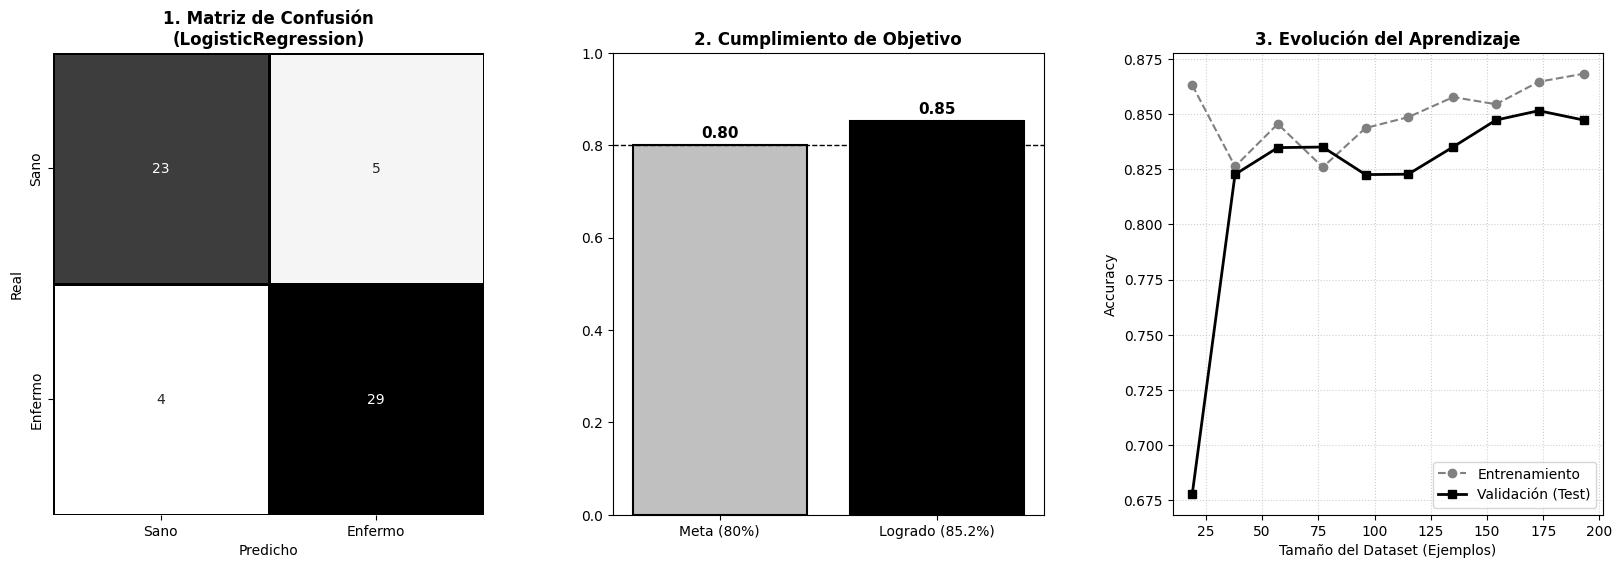

----------------------------------------------------------------------
RESULTADO FINAL: 85.25% de accuracy en test
Supera el objetivo del proyecto (80%). ¡Aprobado!
----------------------------------------------------------------------
Hecho: Visualización, métricas y evolución generadas.


In [7]:
# 1. Predicciones y Métricas Finales
y_pred_final = best_model.predict(X_test)
acc_final = accuracy_score(y_test, y_pred_final)
cm = confusion_matrix(y_test, y_pred_final)

# Configuración del panel
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.subplots_adjust(wspace=0.3)

# --- GRÁFICO 1: Matriz de Confusión (más legible) ---
sns.heatmap(cm, annot=True, fmt='d', cmap='binary', cbar=False,
            xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'],
            linewidths=2, linecolor='black', ax=axes[0])
axes[0].set_title(f'1. Matriz de Confusión\n({best_name})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# --- GRÁFICO 2: Cumplimiento de Objetivo ---
metas = ['Meta (80%)', f'Logrado ({acc_final:.1%})']
valores = [0.80, acc_final]
colores = ['silver', 'black']

bars = axes[1].bar(metas, valores, color=colores, edgecolor='black', linewidth=1.5)
axes[1].set_ylim(0, 1.0)
axes[1].axhline(0.80, color='black', linestyle='--', linewidth=1)
axes[1].set_title('2. Cumplimiento de Objetivo', fontsize=12, fontweight='bold')
axes[1].bar_label(bars, fmt='%.2f', padding=3, fontsize=11, fontweight='bold')

# --- GRÁFICO 3: Curva de Aprendizaje (más puntos) ---
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

axes[2].plot(train_sizes, train_mean, 'o--', color='gray', label='Entrenamiento')
axes[2].plot(train_sizes, test_mean, 's-', color='black', linewidth=2, label='Validación (Test)')
axes[2].set_title('3. Evolución del Aprendizaje', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tamaño del Dataset (Ejemplos)')
axes[2].set_ylabel('Accuracy')
axes[2].legend(loc='lower right')
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.show()

# Mensaje final claro
print("-" * 70)
print(f"RESULTADO FINAL: {acc_final:.2%} de accuracy en test")
if acc_final >= 0.80:
    print("Supera el objetivo del proyecto (80%). ¡Aprobado!")
else:
    print("No supera el 80%. Ajustar hiperparámetros.")
print("-" * 70)
print("Hecho: Visualización, métricas y evolución generadas.")



---

